# Verifier Strategy Benchmarking Analysis

Plots comparing **information gain** and **iterations** across:
- Strategies: entropy, likelihood, random
- Graph sizes: 5v, 6v, 7v, 8v, 9v, 10v
- Blocking percentages: 0%, 25%, 50%, 75%, 100%

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configure plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Configuration
CSV_DIR = Path("trace-artifacts/csv/verifier")
OUTPUT_DIR = Path("benchmarking_images")
OUTPUT_DIR.mkdir(exist_ok=True)

GRAPH_NAMES = ["5v_6e", "6v_7e", "7v_13e", "8v_21e", "9v_19e", "10v_25e"]
BLOCK_PERCENTAGES = [0, 25, 50, 75, 100]
STRATEGIES = ["entropy", "likelihood", "random"]

# Colors for strategies
STRATEGY_COLORS = {
    "entropy": "#2ecc71",      # green
    "likelihood": "#3498db",   # blue  
    "random": "#e74c3c"        # red
}

In [ ]:
def load_data():
    """
    Load iteration data and compute info gain BEFORE finding safe path.
    Excludes iterations where is_safe=True from the info gain calculation.
    """
    # Load iterations CSV (has per-iteration data)
    iter_path = CSV_DIR / "verifier_strategy_comparison_iterations.csv"
    summary_path = CSV_DIR / "verifier_strategy_comparison.csv"
    
    if not iter_path.exists():
        print(f"CSV not found: {iter_path}")
        print("Run test_full_benchmark_suite first to generate the data.")
        return pd.DataFrame()
    
    df_iter = pd.read_csv(iter_path)
    df_summary = pd.read_csv(summary_path) if summary_path.exists() else None
    
    # Calculate info gain only from UNSUCCESSFUL iterations (before finding path)
    # Group by (graph_name, block_percent, strategy) and sum info_gain where is_safe=False
    df_failed = df_iter[df_iter['is_safe'] == False].copy()
    
    info_gain_before = df_failed.groupby(
        ['graph_name', 'num_nodes', 'num_edges', 'block_percent', 'strategy']
    )['info_gain'].sum().reset_index()
    info_gain_before = info_gain_before.rename(columns={'info_gain': 'info_gain_before_success'})
    
    # Count failed iterations
    failed_iters = df_failed.groupby(
        ['graph_name', 'block_percent', 'strategy']
    ).size().reset_index(name='failed_iterations')
    
    # Merge with summary data to get iterations_used and found_safe_path
    if df_summary is not None:
        df = df_summary.merge(
            info_gain_before[['graph_name', 'block_percent', 'strategy', 'info_gain_before_success']],
            on=['graph_name', 'block_percent', 'strategy'],
            how='left'
        )
        df = df.merge(failed_iters, on=['graph_name', 'block_percent', 'strategy'], how='left')
        df['info_gain_before_success'] = df['info_gain_before_success'].fillna(0)
        df['failed_iterations'] = df['failed_iterations'].fillna(0).astype(int)
    else:
        df = info_gain_before
    
    return df

# Load data
df = load_data()
print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print("\nNote: 'info_gain_before_success' = sum of info gain from FAILED iterations only")
df.head(10)

Loaded 90 rows
Columns: ['graph_name', 'num_nodes', 'num_edges', 'block_percent', 'strategy', 'found_safe_path', 'iterations_used', 'total_info_gain']


,graph_name,num_nodes,num_edges,block_percent,strategy,found_safe_path,iterations_used,total_info_gain
0,5v_6e,5,6,0,entropy,True,1,2.079450
1,5v_6e,5,6,0,likelihood,True,1,1.386220
2,5v_6e,5,6,0,random,True,1,1.386280
3,5v_6e,5,6,25,entropy,True,1,2.079530
4,5v_6e,5,6,25,likelihood,True,1,1.386280
5,5v_6e,5,6,25,random,True,1,1.386180
6,5v_6e,5,6,50,entropy,True,8,2.294507
7,5v_6e,5,6,50,likelihood,True,2,1.499587
8,5v_6e,5,6,50,random,True,2,1.416930
9,5v_6e,5,6,75,entropy,True,8,2.294156


## 1. Information Gain by Strategy (Grouped by Graph)

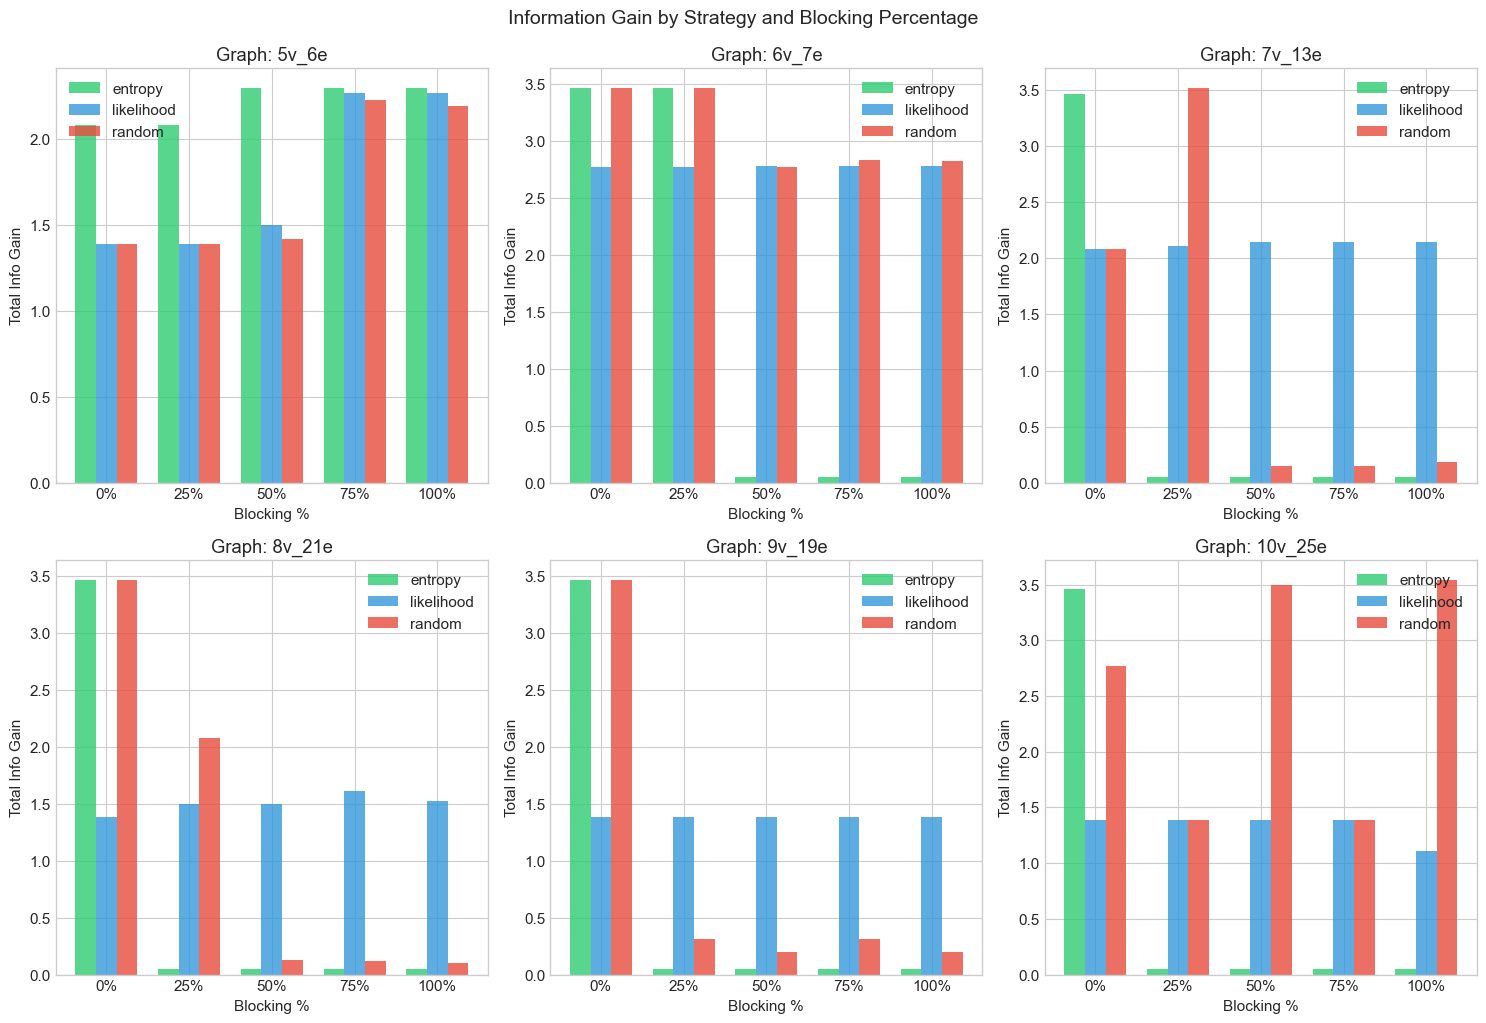

In [ ]:
def plot_info_gain_by_graph(df):
    """Plot info gain BEFORE finding safe path for each strategy, grouped by graph type."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, graph in enumerate(GRAPH_NAMES):
        ax = axes[idx]
        graph_data = df[df['graph_name'] == graph]
        
        x = np.arange(len(BLOCK_PERCENTAGES))
        width = 0.25
        
        for i, strategy in enumerate(STRATEGIES):
            strategy_data = graph_data[graph_data['strategy'] == strategy]
            values = []
            for pct in BLOCK_PERCENTAGES:
                row = strategy_data[strategy_data['block_percent'] == pct]
                if len(row) > 0:
                    values.append(row['info_gain_before_success'].values[0])
                else:
                    values.append(0)
            
            ax.bar(x + i*width, values, width, 
                   label=strategy, color=STRATEGY_COLORS[strategy], alpha=0.8)
        
        ax.set_xlabel('Blocking %')
        ax.set_ylabel('Info Gain (before success)')
        ax.set_title(f'Graph: {graph}')
        ax.set_xticks(x + width)
        ax.set_xticklabels([f'{p}%' for p in BLOCK_PERCENTAGES])
        ax.legend()
    
    plt.tight_layout()
    plt.suptitle('Information Gain Before Finding Safe Path', y=1.02, fontsize=14)
    plt.savefig('benchmarking_images/verifier_info_gain_by_graph.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_info_gain_by_graph(df)

## 2. Average Information Gain by Blocking Percentage

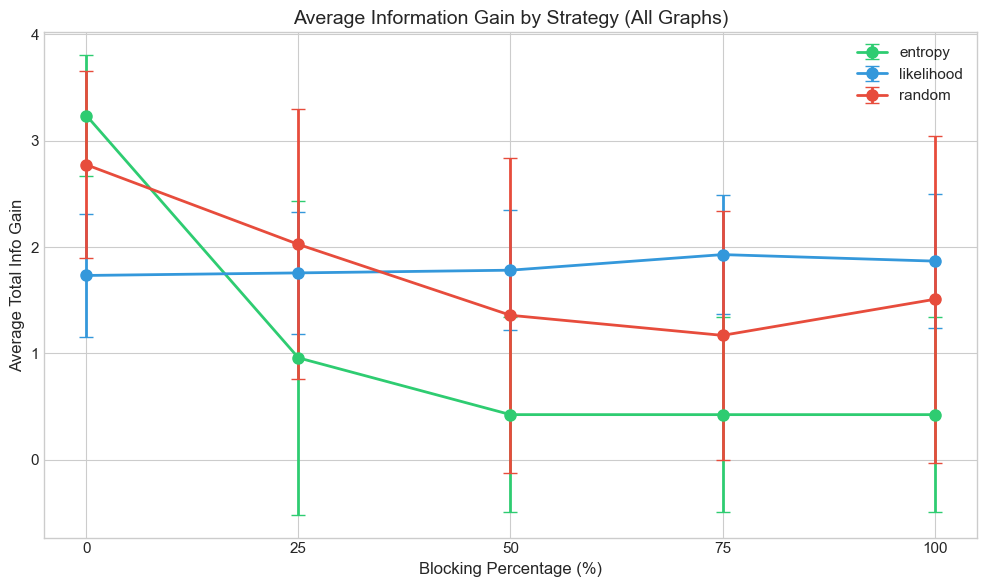

In [ ]:
def plot_info_gain_by_blocking(df):
    """Plot average info gain (before success) across all graphs for each blocking percentage."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for strategy in STRATEGIES:
        strategy_data = df[df['strategy'] == strategy]
        means = strategy_data.groupby('block_percent')['info_gain_before_success'].mean()
        stds = strategy_data.groupby('block_percent')['info_gain_before_success'].std()
        
        ax.errorbar(means.index, means.values, yerr=stds.values,
                   label=strategy, color=STRATEGY_COLORS[strategy],
                   marker='o', markersize=8, linewidth=2, capsize=5)
    
    ax.set_xlabel('Blocking Percentage (%)', fontsize=12)
    ax.set_ylabel('Avg Info Gain (before success)', fontsize=12)
    ax.set_title('Average Information Gain Before Finding Safe Path', fontsize=14)
    ax.legend(fontsize=11)
    ax.set_xticks(BLOCK_PERCENTAGES)
    
    plt.tight_layout()
    plt.savefig('benchmarking_images/verifier_avg_info_gain.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_info_gain_by_blocking(df)

## 3. Iterations to Find Safe Path

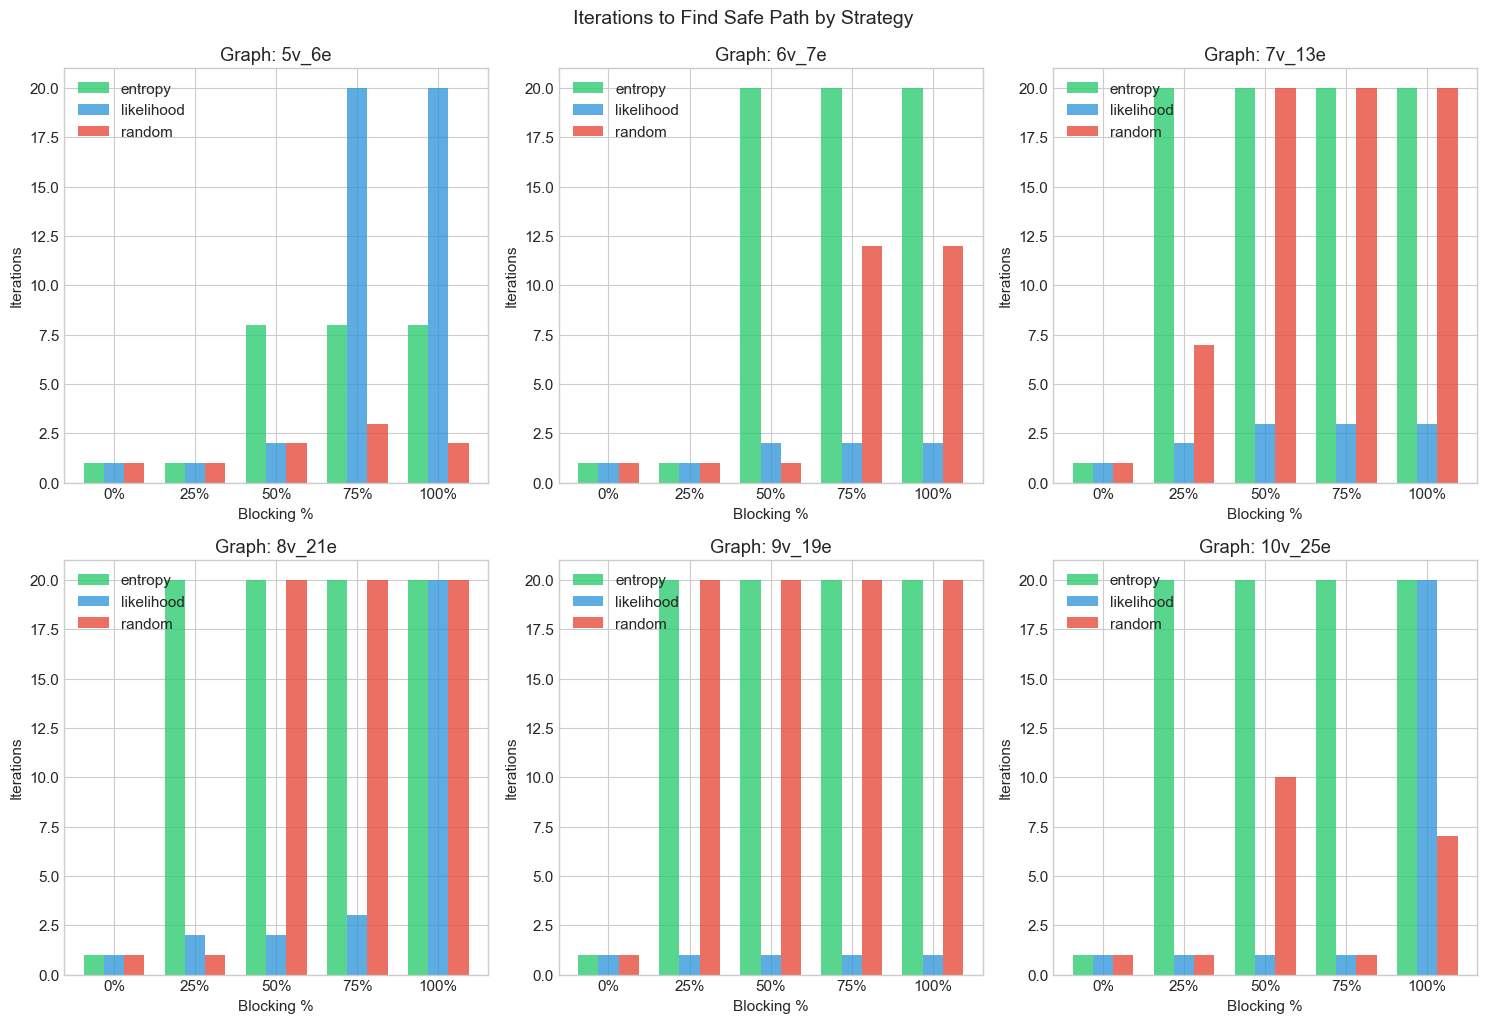

In [14]:
def plot_iterations_by_graph(df):
    """Plot iterations used for each strategy, grouped by graph type."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, graph in enumerate(GRAPH_NAMES):
        ax = axes[idx]
        graph_data = df[df['graph_name'] == graph]
        
        x = np.arange(len(BLOCK_PERCENTAGES))
        width = 0.25
        
        for i, strategy in enumerate(STRATEGIES):
            strategy_data = graph_data[graph_data['strategy'] == strategy]
            values = []
            for pct in BLOCK_PERCENTAGES:
                row = strategy_data[strategy_data['block_percent'] == pct]
                if len(row) > 0:
                    values.append(row['iterations_used'].values[0])
                else:
                    values.append(0)
            
            ax.bar(x + i*width, values, width,
                   label=strategy, color=STRATEGY_COLORS[strategy], alpha=0.8)
        
        ax.set_xlabel('Blocking %')
        ax.set_ylabel('Iterations')
        ax.set_title(f'Graph: {graph}')
        ax.set_xticks(x + width)
        ax.set_xticklabels([f'{p}%' for p in BLOCK_PERCENTAGES])
        ax.legend()
    
    plt.tight_layout()
    plt.suptitle('Iterations to Find Safe Path by Strategy', y=1.02, fontsize=14)
    plt.savefig('benchmarking_images/verifier_iterations_by_graph.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_iterations_by_graph(df)

## 4. Combined Overview Plot

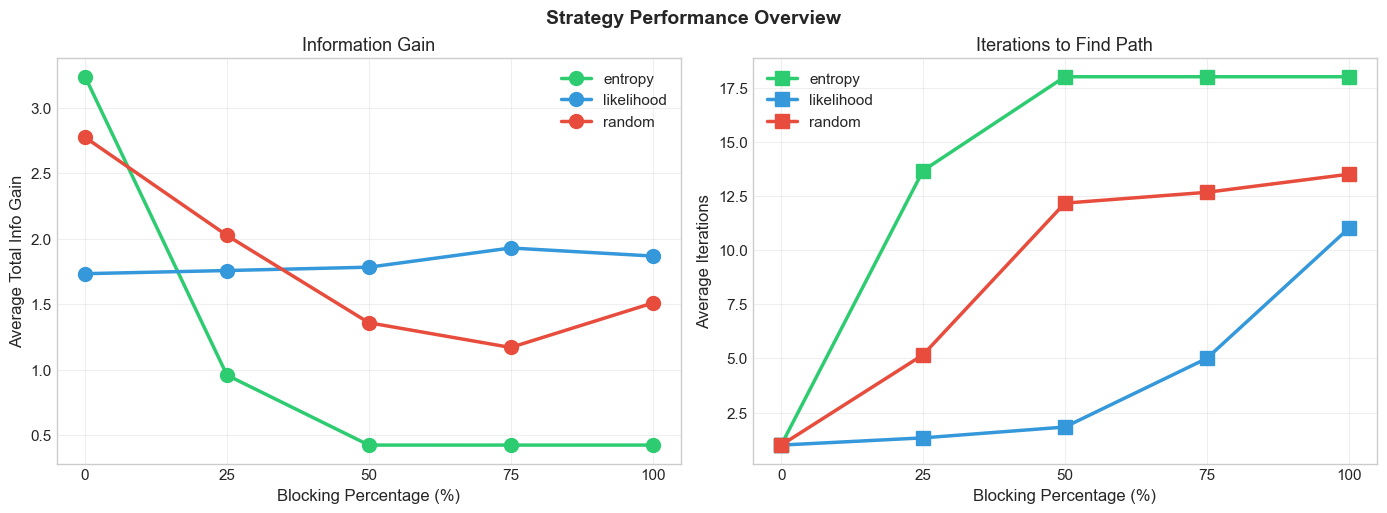

In [ ]:
def plot_combined_overview(df):
    """Create a combined overview with info gain (before success) and iterations side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Info Gain (before success)
    ax1 = axes[0]
    for strategy in STRATEGIES:
        strategy_data = df[df['strategy'] == strategy]
        means = strategy_data.groupby('block_percent')['info_gain_before_success'].mean()
        ax1.plot(means.index, means.values, marker='o', markersize=10,
                label=strategy, color=STRATEGY_COLORS[strategy], linewidth=2.5)
    
    ax1.set_xlabel('Blocking Percentage (%)', fontsize=12)
    ax1.set_ylabel('Avg Info Gain (before success)', fontsize=12)
    ax1.set_title('Information Gain Before Finding Path', fontsize=13)
    ax1.legend(fontsize=11)
    ax1.set_xticks(BLOCK_PERCENTAGES)
    ax1.grid(True, alpha=0.3)
    
    # Iterations
    ax2 = axes[1]
    for strategy in STRATEGIES:
        strategy_data = df[df['strategy'] == strategy]
        means = strategy_data.groupby('block_percent')['iterations_used'].mean()
        ax2.plot(means.index, means.values, marker='s', markersize=10,
                label=strategy, color=STRATEGY_COLORS[strategy], linewidth=2.5)
    
    ax2.set_xlabel('Blocking Percentage (%)', fontsize=12)
    ax2.set_ylabel('Average Iterations', fontsize=12)
    ax2.set_title('Iterations to Find Path', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.set_xticks(BLOCK_PERCENTAGES)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Strategy Performance Overview', y=1.02, fontsize=14, fontweight='bold')
    plt.savefig('benchmarking_images/verifier_combined_overview.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_combined_overview(df)

## 5. Strategy Comparison Summary Table

In [ ]:
def create_summary_table(df):
    """Create summary table comparing strategies."""
    summary = df.groupby('strategy').agg({
        'info_gain_before_success': ['mean', 'std', 'min', 'max'],
        'failed_iterations': ['mean', 'std', 'min', 'max'],
        'iterations_used': ['mean', 'std', 'min', 'max'],
        'found_safe_path': 'mean'  # Success rate
    }).round(3)
    
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
    summary = summary.rename(columns={'found_safe_path_mean': 'success_rate'})
    
    print("\n" + "="*80)
    print("STRATEGY COMPARISON SUMMARY")
    print("="*80)
    print("Note: info_gain_before_success = cumulative info gain from FAILED iterations only")
    return summary

summary = create_summary_table(df)
summary


STRATEGY COMPARISON SUMMARY


,total_info_gain_mean,total_info_gain_std,total_info_gain_min,total_info_gain_max,iterations_used_mean,iterations_used_std,iterations_used_min,iterations_used_max,success_rate
strategy,,,,,,,,,
entropy,1.094,1.446,0.051,3.466,13.733,8.594,1,20,0.367
likelihood,1.814,0.546,1.110,2.782,4.033,6.408,1,20,0.867
random,1.767,1.331,0.105,3.544,8.900,8.588,1,20,0.667


## 6. Heatmaps: Info Gain by Graph and Blocking %

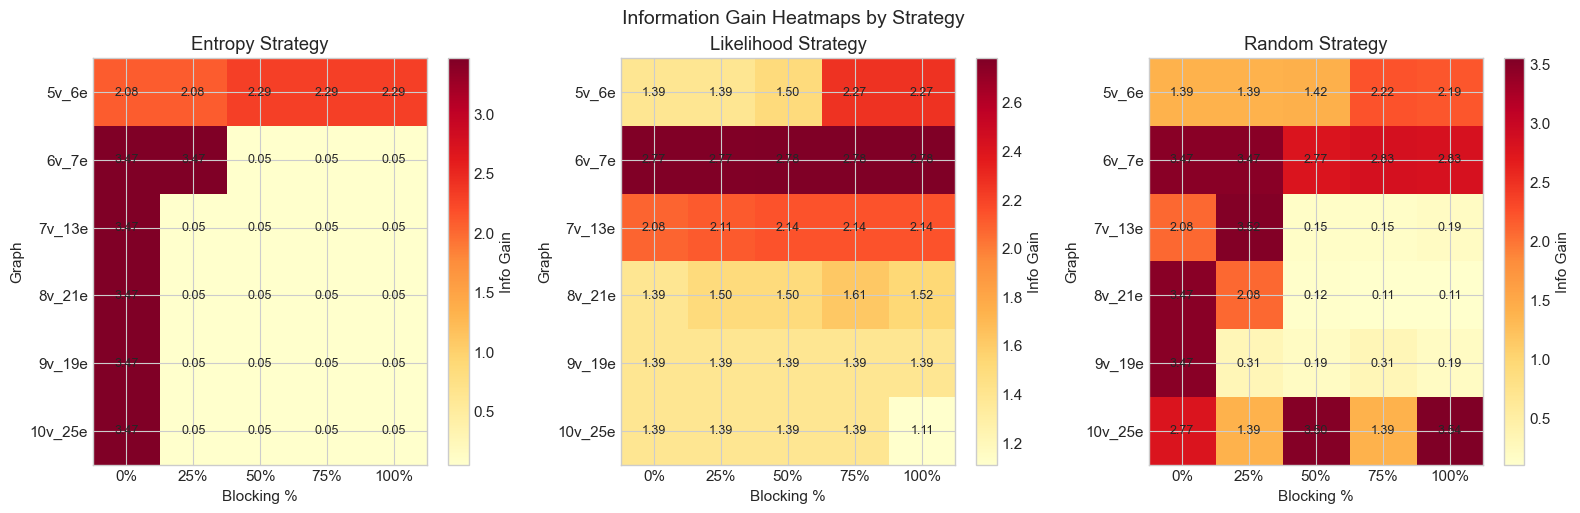

In [ ]:
def plot_heatmaps(df):
    """Plot heatmaps of info gain (before success) for each strategy."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for idx, strategy in enumerate(STRATEGIES):
        ax = axes[idx]
        strategy_data = df[df['strategy'] == strategy]
        
        # Create pivot table
        pivot = strategy_data.pivot_table(
            values='info_gain_before_success',
            index='graph_name',
            columns='block_percent',
            aggfunc='mean'
        )
        
        # Reorder rows
        pivot = pivot.reindex(GRAPH_NAMES)
        
        im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
        
        ax.set_xticks(range(len(BLOCK_PERCENTAGES)))
        ax.set_xticklabels([f'{p}%' for p in BLOCK_PERCENTAGES])
        ax.set_yticks(range(len(GRAPH_NAMES)))
        ax.set_yticklabels(GRAPH_NAMES)
        ax.set_xlabel('Blocking %')
        ax.set_ylabel('Graph')
        ax.set_title(f'{strategy.capitalize()} Strategy')
        
        # Add text annotations
        for i in range(len(GRAPH_NAMES)):
            for j in range(len(BLOCK_PERCENTAGES)):
                if i < pivot.values.shape[0] and j < pivot.values.shape[1]:
                    val = pivot.values[i, j]
                    if not np.isnan(val):
                        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9)
        
        plt.colorbar(im, ax=ax, label='Info Gain')
    
    plt.tight_layout()
    plt.suptitle('Information Gain Before Success - Heatmaps by Strategy', y=1.02, fontsize=14)
    plt.savefig('benchmarking_images/verifier_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_heatmaps(df)